# VRPTW Walkthrough

**Vehicle Routing Problem with Time Windows.** Same fleet-of-vehicles-from-a-depot setup as CVRP, but each customer now has a *time window* — an interval `[earliest_i, latest_i]` during which the visit must start. Add service times, vehicle working hours, and capacity, and you have a problem that looks an awful lot like real-world delivery routing.

## What's new in the OR-Tools API

The same dimension machinery from CVRP, but now we add a **Time** dimension alongside Capacity:

| concept | CVRP | VRPTW |
| --- | --- | --- |
| transit callback for arc cost | distance | distance (still the objective) |
| extra callback | demand | **travel time + service time** |
| dimension | Capacity | Capacity *and* Time |
| per-node bounds | none | `time_dim.CumulVar(idx).SetRange(a, b)` |
| slack | 0 (load only grows) | non-zero (vehicle can *wait* if it arrives early) |

Three concrete new method calls:

1. `routing.RegisterTransitCallback(time_cb)` — registers a *two-argument* callback that returns the time it takes to leave `i`, travel to `j`, and arrive at `j`. By convention this is `service_time[i] + travel_time[i][j]`.
2. `routing.AddDimension(time_idx, slack_max, horizon, fix_start, "Time")` — like `AddDimensionWithVehicleCapacity` but uniform across vehicles and with **non-zero slack** so a vehicle can sit idle when it's early.
3. `time_dim.CumulVar(idx).SetRange(a, b)` — per-node window. The cumul variable at node `i` represents the arrival time *at* node `i`; bounding it `[a, b]` enforces the window.

In [1]:
%load_ext autoreload
%autoreload 2

import math
import random

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

from ortools.constraint_solver import pywrapcp, routing_enums_pb2

random.seed(23)
np.random.seed(23)

## 1. An instance with time windows

We'll model a small last-mile delivery problem:

- 15 customers around a central depot.
- Coordinates in a 60×60 km grid. Vehicle speed is 1 km/min, so **distance in km ≈ travel time in minutes** — keeps the units clean.
- Service time at every customer: 5 minutes.
- Working day: minute 0 to minute 480 (an 8-hour day).
- Each customer has a 60-minute window scattered between 30 min and 420 min into the day.
- Per-customer demand 1–10 units, vehicle capacity 30, 4 vehicles available.

In [2]:
N_CUSTOMERS = 15
DEPOT = 0
HORIZON = 480           # working-day length in minutes
SERVICE_TIME = 5        # per-customer service in minutes
WINDOW_WIDTH = 60       # length of each customer's window
VEHICLE_CAPACITY = 30
NUM_VEHICLES = 4

points = [(30.0, 30.0)] + [
    (random.uniform(0, 60), random.uniform(0, 60)) for _ in range(N_CUSTOMERS)
]
demands = [0] + [random.randint(1, 10) for _ in range(N_CUSTOMERS)]

def make_int_distance(pts):
    """Integer Euclidean distance — for VRPTW we want km == minutes, so no extra scaling."""
    n = len(pts)
    m = [[0] * n for _ in range(n)]
    for i, (xi, yi) in enumerate(pts):
        for j, (xj, yj) in enumerate(pts):
            if i != j:
                m[i][j] = int(round(math.hypot(xi - xj, yi - yj)))
    return m

distance = make_int_distance(points)

# Random 60-min windows, spaced through the day.
windows = [(0, HORIZON)]  # depot is open all day
for _ in range(N_CUSTOMERS):
    start = random.randint(30, HORIZON - WINDOW_WIDTH - 30)
    windows.append((start, start + WINDOW_WIDTH))

print(f"{N_CUSTOMERS} customers, total demand {sum(demands)} (fleet capacity {NUM_VEHICLES * VEHICLE_CAPACITY})")
for i in range(1, len(points)):
    print(f"  c{i:>2d}: pos=({points[i][0]:5.1f},{points[i][1]:5.1f})  demand={demands[i]:>2d}  window=[{windows[i][0]:>3d},{windows[i][1]:>3d}]")

15 customers, total demand 92 (fleet capacity 120)
  c 1: pos=( 55.5, 56.9)  demand= 6  window=[328,388]
  c 2: pos=( 53.5,  5.0)  demand=10  window=[ 88,148]
  c 3: pos=( 35.5, 25.4)  demand= 2  window=[ 72,132]
  c 4: pos=( 31.8,  7.8)  demand= 8  window=[ 80,140]
  c 5: pos=( 11.5, 26.7)  demand= 3  window=[248,308]
  c 6: pos=( 13.3, 27.3)  demand= 8  window=[ 49,109]
  c 7: pos=(  1.5,  5.1)  demand=10  window=[320,380]
  c 8: pos=( 42.6, 25.3)  demand= 8  window=[171,231]
  c 9: pos=( 30.8, 44.1)  demand= 3  window=[323,383]
  c10: pos=( 21.5,  3.5)  demand= 3  window=[173,233]
  c11: pos=( 47.0, 35.3)  demand= 3  window=[332,392]
  c12: pos=( 39.5, 37.3)  demand= 9  window=[199,259]
  c13: pos=( 58.2, 21.8)  demand= 6  window=[ 85,145]
  c14: pos=( 45.6, 22.1)  demand= 9  window=[219,279]
  c15: pos=( 34.3, 39.6)  demand= 4  window=[177,237]


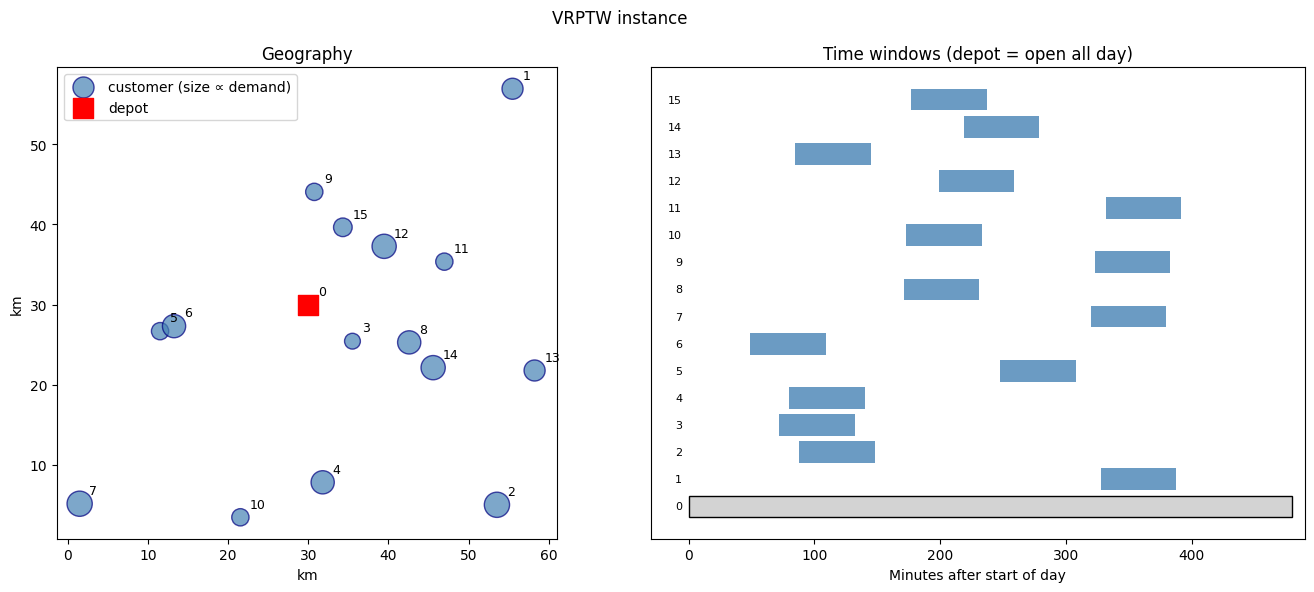

In [3]:
def plot_instance(points, demands, windows, title="VRPTW instance"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    xs = [p[0] for p in points]; ys = [p[1] for p in points]
    sizes = [80 + d * 25 for d in demands]
    ax1.scatter(xs[1:], ys[1:], s=sizes[1:], c="steelblue", alpha=0.7,
                edgecolors="navy", label="customer (size \u221d demand)")
    ax1.scatter(*points[0], c="red", s=200, marker="s", zorder=5, label="depot")
    for i, (x, y) in enumerate(points):
        ax1.annotate(str(i), (x, y), textcoords="offset points", xytext=(7, 7), fontsize=9)
    ax1.set_aspect("equal"); ax1.legend(); ax1.set_title("Geography")
    ax1.set_xlabel("km"); ax1.set_ylabel("km")

    # Time windows as horizontal bars
    for i, (a, b) in enumerate(windows):
        if i == 0:
            ax2.barh(i, b - a, left=a, color="lightgrey", edgecolor="black")
        else:
            ax2.barh(i, b - a, left=a, color="steelblue", alpha=0.8)
        ax2.annotate(str(i), (-5, i), textcoords="data", ha="right", va="center", fontsize=8)
    ax2.set_yticks([])
    ax2.set_xlabel("Minutes after start of day")
    ax2.set_xlim(-30, HORIZON + 10)
    ax2.set_title("Time windows (depot = open all day)")
    plt.suptitle(title)
    plt.tight_layout(); plt.show()

plot_instance(points, demands, windows)

## 2. Building the VRPTW model

The skeleton is identical to CVRP — manager, model, distance callback for cost, demand callback for capacity. The new pieces are:

- a **time callback** that returns `service_time[from] + travel_time[from][to]`,
- a **Time dimension** registered with non-zero slack (so vehicles can wait when they arrive early),
- a **`SetRange(a, b)` call per node** to enforce each customer's window,
- and depot-window enforcement on each vehicle's start and end.

The two finalizer calls at the bottom are an OR-Tools idiom: they tell the solver to push the start time as late as possible and the end time as early as possible *given the rest of the solution*. Without them you get arbitrarily early start times that look weird in the timeline.

In [4]:
def build_vrptw_model(
    distance, demands, windows, capacities,
    service_time, horizon, depot=0, wait_slack=60,
):
    n = len(distance)
    num_vehicles = len(capacities)
    manager = pywrapcp.RoutingIndexManager(n, num_vehicles, depot)
    routing = pywrapcp.RoutingModel(manager)

    # Arc cost: distance (minimise total km).
    def distance_cb(fi, ti):
        return distance[manager.IndexToNode(fi)][manager.IndexToNode(ti)]
    transit_idx = routing.RegisterTransitCallback(distance_cb)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)

    # Capacity dimension (unchanged from CVRP).
    def demand_cb(fi):
        return demands[manager.IndexToNode(fi)]
    demand_idx = routing.RegisterUnaryTransitCallback(demand_cb)
    routing.AddDimensionWithVehicleCapacity(
        demand_idx, 0, list(capacities), True, "Capacity",
    )

    # Time dimension: leaving i for j costs service_time[i] + travel(i, j).
    def time_cb(fi, ti):
        from_node = manager.IndexToNode(fi)
        to_node = manager.IndexToNode(ti)
        st = 0 if from_node == depot else service_time
        return st + distance[from_node][to_node]
    time_idx = routing.RegisterTransitCallback(time_cb)
    routing.AddDimension(
        time_idx,
        wait_slack,     # how long a vehicle may wait if it arrives early
        horizon,        # maximum value of cumul (i.e. don't return after EOD)
        False,          # don't force start time to 0 — we set it below
        "Time",
    )
    time_dim = routing.GetDimensionOrDie("Time")

    # Per-customer time windows.
    for node in range(n):
        if node == depot:
            continue
        a, b = windows[node]
        time_dim.CumulVar(manager.NodeToIndex(node)).SetRange(a, b)

    # Depot windows for each vehicle's start and end.
    depot_open, depot_close = windows[depot]
    for v in range(num_vehicles):
        time_dim.CumulVar(routing.Start(v)).SetRange(depot_open, depot_close)
        time_dim.CumulVar(routing.End(v)).SetRange(depot_open, depot_close)

    # Encourage tight start/end times in the printed timeline.
    for v in range(num_vehicles):
        routing.AddVariableMinimizedByFinalizer(time_dim.CumulVar(routing.Start(v)))
        routing.AddVariableMinimizedByFinalizer(time_dim.CumulVar(routing.End(v)))

    return manager, routing, time_dim


def solve(routing, time_limit=5):
    params = pywrapcp.DefaultRoutingSearchParameters()
    params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    params.time_limit.FromSeconds(time_limit)
    return routing.SolveWithParameters(params)


manager, routing, time_dim = build_vrptw_model(
    distance, demands, windows,
    capacities=[VEHICLE_CAPACITY] * NUM_VEHICLES,
    service_time=SERVICE_TIME,
    horizon=HORIZON,
)
solution = solve(routing, time_limit=5)
print("Status:", routing.status(), " Total distance:", solution.ObjectiveValue(), "km")

Status: 1  Total distance: 351 km


## 3. Reading off the timeline

For each visited node, the `time_dim.CumulVar(idx)` solution value is the **arrival time**. Combined with the service time and the window, that gives us a full picture: when the driver arrived, when they actually started service (≥ window open), and when they left.

In [5]:
def extract_schedule(manager, routing, time_dim, solution, demands, service_time, depot=0):
    rows = []
    routes = []
    for v in range(routing.vehicles()):
        idx = routing.Start(v)
        route = []
        while not routing.IsEnd(idx):
            node = manager.IndexToNode(idx)
            cv = time_dim.CumulVar(idx)
            arr_min = solution.Min(cv)
            arr_max = solution.Max(cv)
            st = 0 if node == depot else service_time
            rows.append({
                "vehicle": v, "node": node,
                "arrive": arr_min, "leave": arr_min + st,
                "slack_min": arr_max - arr_min,
                "demand": demands[node],
            })
            route.append(node)
            idx = solution.Value(routing.NextVar(idx))
        node = manager.IndexToNode(idx)
        cv = time_dim.CumulVar(idx)
        rows.append({
            "vehicle": v, "node": node,
            "arrive": solution.Min(cv), "leave": solution.Min(cv),
            "slack_min": solution.Max(cv) - solution.Min(cv),
            "demand": demands[node],
        })
        route.append(node)
        routes.append(route)
    return pd.DataFrame(rows), routes


schedule_df, routes = extract_schedule(manager, routing, time_dim, solution, demands, SERVICE_TIME)
for v in range(NUM_VEHICLES):
    sub = schedule_df[schedule_df["vehicle"] == v]
    if len(sub) <= 2:
        print(f"vehicle {v}: --- unused ---")
        continue
    visits = sub[sub["node"] != DEPOT]
    print(f"vehicle {v}: load {visits['demand'].sum():>2d}/{VEHICLE_CAPACITY}, "
          f"depart {int(sub.iloc[0]['leave']):>3d}, return {int(sub.iloc[-1]['arrive']):>3d}")
    for _, row in sub.iterrows():
        if row["node"] == DEPOT:
            continue
        w = windows[int(row["node"])]
        print(f"    c{int(row['node']):>2d}  arrive@{int(row['arrive']):>3d}  leave@{int(row['leave']):>3d}  window=[{w[0]:>3d},{w[1]:>3d}]")

vehicle 0: load 24/30, depart   0, return 163
    c 4  arrive@ 80  leave@ 85  window=[ 80,140]
    c 2  arrive@107  leave@112  window=[ 88,148]
    c13  arrive@129  leave@134  window=[ 85,145]
vehicle 1: load 24/30, depart   6, return 363
    c 6  arrive@ 83  leave@ 88  window=[ 49,109]
    c10  arrive@173  leave@178  window=[173,233]
    c 5  arrive@248  leave@253  window=[248,308]
    c 7  arrive@320  leave@325  window=[320,380]
vehicle 2: load 25/30, depart 106, return 398
    c15  arrive@177  leave@182  window=[177,237]
    c12  arrive@238  leave@243  window=[199,259]
    c 1  arrive@328  leave@333  window=[328,388]
    c11  arrive@356  leave@361  window=[332,392]
    c 9  arrive@379  leave@384  window=[323,383]
vehicle 3: load 19/30, depart  32, return 241
    c 3  arrive@ 99  leave@104  window=[ 72,132]
    c 8  arrive@171  leave@176  window=[171,231]
    c14  arrive@219  leave@224  window=[219,279]


## 4. Visualising routes and the schedule

Two views, side by side: the geographic routes (colour per vehicle), and a Gantt-style chart of when each vehicle is busy at each customer. The grey bars on the Gantt chart are the *windows*, and the coloured blocks are when the driver is actually servicing the customer.

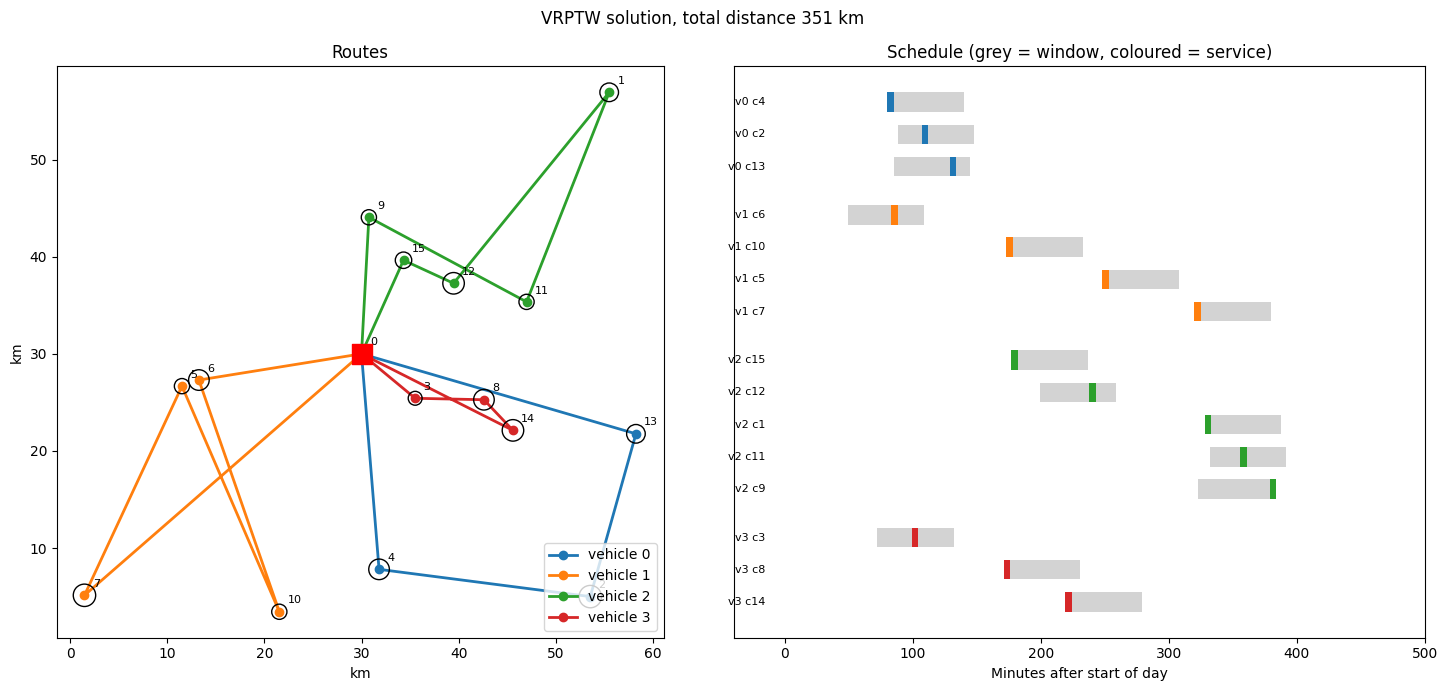

In [6]:
def plot_vrptw(points, routes, schedule_df, windows, demands, service_time, num_vehicles, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, num_vehicles)))

    # Geographic
    for v, route in enumerate(routes):
        if len(route) <= 2:
            continue
        rx = [points[i][0] for i in route]
        ry = [points[i][1] for i in route]
        ax1.plot(rx, ry, "-o", color=colors[v], linewidth=2, label=f"vehicle {v}")
    sizes = [60 + d * 20 for d in demands]
    xs = [p[0] for p in points]; ys = [p[1] for p in points]
    ax1.scatter(xs[1:], ys[1:], s=sizes[1:], facecolors="none", edgecolors="black", zorder=3)
    ax1.scatter(*points[0], c="red", s=200, marker="s", zorder=5)
    for i, (x, y) in enumerate(points):
        ax1.annotate(str(i), (x, y), textcoords="offset points", xytext=(6, 6), fontsize=8)
    ax1.set_aspect("equal"); ax1.legend(loc="lower right"); ax1.set_title("Routes")
    ax1.set_xlabel("km"); ax1.set_ylabel("km")

    # Gantt
    y_positions = {}
    y = 0
    for v in range(num_vehicles):
        sub = schedule_df[(schedule_df["vehicle"] == v) & (schedule_df["node"] != DEPOT)]
        if len(sub) == 0:
            continue
        for _, row in sub.iterrows():
            node = int(row["node"])
            wa, wb = windows[node]
            ax2.barh(y, wb - wa, left=wa, color="lightgrey", height=0.6, zorder=1)
            ax2.barh(y, row["leave"] - row["arrive"], left=row["arrive"],
                     color=colors[v], height=0.6, zorder=2)
            ax2.text(-15, y, f"v{v} c{node}", ha="right", va="center", fontsize=8)
            y_positions[(v, node)] = y
            y += 1
        y += 0.5  # gap between vehicles
    ax2.set_xlim(-40, HORIZON + 20)
    ax2.set_yticks([])
    ax2.invert_yaxis()
    ax2.set_xlabel("Minutes after start of day")
    ax2.set_title("Schedule (grey = window, coloured = service)")
    plt.suptitle(title); plt.tight_layout(); plt.show()

plot_vrptw(points, routes, schedule_df, windows, demands, SERVICE_TIME, NUM_VEHICLES,
           title=f"VRPTW solution, total distance {solution.ObjectiveValue()} km")

## 5. Tightening the windows

What happens as we squeeze the customer windows? In the limit (zero-width windows), the solver would need a vehicle for almost every customer. Watch the total distance climb as the windows shrink — vehicles can no longer chain neighbouring customers because they don't arrive in the right minute.

In [7]:
def shrink_windows(base_windows, target_width):
    """Centre the original window on its midpoint and reduce its width."""
    out = [base_windows[0]]  # depot unchanged
    for a, b in base_windows[1:]:
        mid = (a + b) // 2
        half = target_width // 2
        out.append((max(0, mid - half), min(HORIZON, mid + half)))
    return out


rows = []
for width in [120, 60, 30, 20, 10]:
    w = shrink_windows(windows, width)
    manager_t, routing_t, time_dim_t = build_vrptw_model(
        distance, demands, w,
        capacities=[VEHICLE_CAPACITY] * NUM_VEHICLES,
        service_time=SERVICE_TIME, horizon=HORIZON,
    )
    sol = solve(routing_t, time_limit=3)
    if sol is None:
        rows.append({"window_width": width, "status": routing_t.status(),
                     "objective": None, "vehicles_used": None})
        continue
    _, rts = extract_schedule(manager_t, routing_t, time_dim_t, sol, demands, SERVICE_TIME)
    used = sum(1 for r in rts if len(r) > 2)
    rows.append({"window_width": width, "status": routing_t.status(),
                 "objective": sol.ObjectiveValue(), "vehicles_used": used})

pd.DataFrame(rows)

,window_width,status,objective,vehicles_used
0,120,1,320.0,4.0
1,60,1,351.0,4.0
2,30,1,390.0,4.0
3,20,1,419.0,4.0
4,10,4,NaN,NaN


Reading the table:

- A solver **status of 1** means a solution was found; any other status (here, 4) means the solver failed within the time limit — either the problem is infeasible or the search couldn't find a route in 3 seconds.
- As windows shrink, total distance grows: a vehicle that could chain two nearby customers in the wide-window case now has to make two separate runs because their windows don't overlap with the travel time.
- At very tight widths the problem becomes effectively infeasible for 4 vehicles — too many customers want service in overlapping minutes.

## Where to go next

VRPTW is the workhorse VRP variant in industry. From here, the natural extensions are mostly *more dimensions*:

- **Pickup and delivery (PDPTW)** — pair customers so that each pickup happens before its corresponding delivery on the *same* vehicle. `routing.AddPickupAndDelivery(p_idx, d_idx)`.
- **Multiple depots** — `RoutingIndexManager(n, K, starts, ends)`.
- **Soft time windows** — penalty per minute late or early, modelled with `time_dim.SetCumulVarSoftUpperBound(idx, ub, coef)`.
- **Driver breaks** — `time_dim.SetBreakIntervalsOfVehicle(...)` for mandatory rest periods.

## Promoting to `vrp_lib`

The next commit packages this notebook's `build_vrptw_model` + schedule extraction into `vrp_lib.solve_vrptw`, returning a `SolveResult` plus a per-stop schedule (`vehicle`, `node`, `arrive`, `leave`, `slack`). Future notebooks can then write:

```python
from vrp_lib import solve_vrptw

result = solve_vrptw(
    distance, demands, windows,
    vehicle_capacities=[30]*4,
    service_time=5, horizon=480,
)
# result.routes, result.loads, result.total_distance, result.schedule
```

Backed by a test in `tests/test_vrptw.py` so the time-window constraint can't silently regress.